<a href="https://colab.research.google.com/github/Selvapriya05/Selvapriya-Codeboosters-2026/blob/main/Day_10/Day_10_Miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("/content/student_performance.csv")
print(df.head(5))

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [5]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()

# Store dataframe into SQL table
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

# Count rows
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]

print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")


Database 'college.db' created successfully!
Table 'students' has 30 rows


In [6]:
# Query 1
query1 = """
SELECT student_id, name, department, math_score, attendance_percentage
FROM students
LIMIT 10;
"""
pd.read_sql_query(query1, conn)

,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


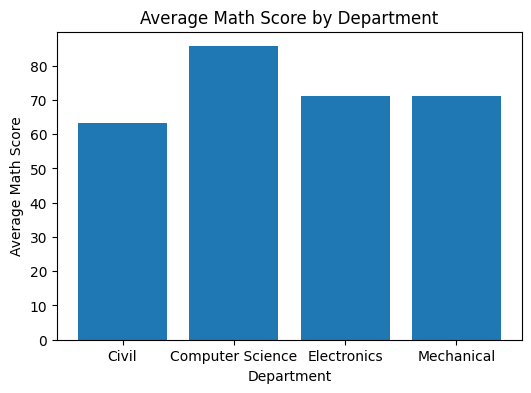

In [7]:
#Chart

avg_scores = df.groupby('department')['math_score'].mean()

plt.figure(figsize=(6,4))
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Math Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Math Score")
plt.show()

In [8]:
df = pd.read_csv("student_performance.csv")
print("OLD DATA")
print(df.head())

OLD DATA
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  

In [10]:

df = pd.read_csv("student_performance.csv")

# Replace cities
df["city"] = df["city"].replace({
    "Mumbai": "Bangalore",
    "Ahmedabad":"pune",
    "Delhi": "Chennai",
    "Hyderabad":"mumbai"
})

print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92  Bangalore            2023  
1                     87       pune            2023  
2       

In [11]:
#check missing values

df.isnull().sum()

,0
student_id,0
name,0
age,0
gender,0
department,0
semester,0
math_score,0
science_score,0
english_score,0
programming_score,0


In [13]:

# Load data
df = pd.read_csv("student_performance.csv")

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df["math_score"] = df["math_score"].fillna(df["math_score"].mean())
df["science_score"] = df["science_score"].fillna(df["science_score"].mean())
df["english_score"] = df["english_score"].fillna(df["english_score"].mean())
df["programming_score"] = df["programming_score"].fillna(df["programming_score"].mean())

df["department"] = df["department"].fillna(df["department"].mode()[0])
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["city"] = df["city"].fillna(df["city"].mode()[0])

# Remove invalid scores (0–100 range)
df = df[
    (df["math_score"].between(0, 100)) &
    (df["science_score"].between(0, 100)) &
    (df["english_score"].between(0, 100)) &
    (df["programming_score"].between(0, 100))
]

# Standardize text columns
df["gender"] = df["gender"].str.strip().str.lower()
df["department"] = df["department"].str.strip()
df["city"] = df["city"].str.strip()

# Final cleaned data
print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    male  Computer Science         2   
1        1002   Priya Patel   20  female  Computer Science         2   
2        1003   Rohit Verma   19    male       Electronics         2   
3        1004   Sneha Reddy   20  female        Mechanical         2   
4        1005    Arjun Nair   19    male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [14]:
#API Key and fetch the data

import requests
api_key = "e4c00c1634c23e0301a5298fec69b74c"
city = "Coimbatore"
url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"

In [15]:
#Fetch the data

response = requests.get(url)
data = response.json()
print(data)

{'coord': {'lon': 76.9667, 'lat': 11}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 30.5, 'feels_like': 32.17, 'temp_min': 30.5, 'temp_max': 30.5, 'pressure': 1007, 'humidity': 52, 'sea_level': 1007, 'grnd_level': 958}, 'visibility': 10000, 'wind': {'speed': 8.25, 'deg': 241, 'gust': 9.99}, 'clouds': {'all': 100}, 'dt': 1780653938, 'sys': {'country': 'IN', 'sunrise': 1780619313, 'sunset': 1780665173}, 'timezone': 19800, 'id': 1273865, 'name': 'Coimbatore', 'cod': 200}


In [16]:
print("City:", data["name"])
print("Temperature:", data["main"]["temp"])
print("Weather:", data["weather"][0]["description"])
print("Humidity:", data["main"]["humidity"])

City: Coimbatore
Temperature: 30.5
Weather: overcast clouds
Humidity: 52


In [17]:
!pip install pyspark

In [18]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("StudentETL") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [19]:
df = spark.read.csv("student_performance.csv", header=True, inferSchema=True)

df.show(5)

+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|    Delhi|          2023

In [20]:
bronze_df = spark.read.csv("student_performance.csv", header=True, inferSchema=True)

print("BRONZE DATA")
bronze_df.show(5)

BRONZE DATA
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|        name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|    Delhi|  

In [21]:
silver_df = bronze_df.dropna()

# Example transformation
silver_df = silver_df.withColumnRenamed("name", "student_name")

print("SILVER DATA")
silver_df.show(5)

SILVER DATA
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|student_id|student_name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|           61|               55|                   78|    Delhi|  

In [22]:
from pyspark.sql.functions import col

gold_df = silver_df.withColumn(
    "total_score",
    col("math_score") + col("science_score") +
    col("english_score") + col("programming_score")
)

print("GOLD DATA")
gold_df.show(5)

GOLD DATA
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+-----------+
|student_id|student_name|age|gender|      department|semester|math_score|science_score|english_score|programming_score|attendance_percentage|     city|admission_year|total_score|
+----------+------------+---+------+----------------+--------+----------+-------------+-------------+-----------------+---------------------+---------+--------------+-----------+
|      1001|Aarav Sharma| 19|  Male|Computer Science|       2|        85|           78|           72|               91|                   92|   Mumbai|          2023|        326|
|      1002| Priya Patel| 20|Female|Computer Science|       2|        76|           82|           88|               79|                   87|Ahmedabad|          2023|        325|
|      1003| Rohit Verma| 19|  Male|     Electronics|       2|        65|           74|        

In [40]:
import pandas as pd
from textblob import TextBlob

df = pd.read_csv("student_performance.csv")

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["student_performance"].apply(get_sentiment)

print(df[["student_performance", "sentiment"]])

KeyError: 'student_performance'

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

df = pd.read_csv("student_performance.csv")

# Predict total score
df["total_score"] = (
    df["math_score"] +
    df["science_score"] +
    df["english_score"] +
    df["programming_score"]
)

X = df[["math_score", "science_score", "english_score",
        "programming_score", "attendance_percentage"]]

y = df["total_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Limit tree depth to avoid overfitting
model = DecisionTreeRegressor(max_depth=5, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("=== Decision Tree (max_depth=5) ===")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))

=== Decision Tree (max_depth=5) ===
MAE : 12.44
RMSE: 18.95
R2  : 0.8767
